In [ ]:
# Install all required packages
!pip install pandas numpy scikit-learn vaderSentiment
!pip install sentence-transformers
!pip install bertopic
!pip install umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.4 MB/s eta 0:00:00


Total posts: 1709
Total comments: 16574
Index(['post_id', 'title', 'author', 'created_utc', 'score', 'num_comments',
       'image_url', 'permalink', 'comments', 'local_paths', 'num_images',
       'crops', 'person_labels', 'context_labels'],
      dtype='object')
Index(['post_id', 'sentiment'], dtype='object')
Posts with sentiment: 1709
Total images: 1193
Images after cleaning: 1193

IMAGE COUNT BY PERSON CATEGORY

person
solo      1155
selfie      29
group        9
Name: count, dtype: int64

Average Sentiment by PERSON Category

person
group     0.796088
solo      0.509529
selfie    0.428150
Name: sentiment, dtype: float64


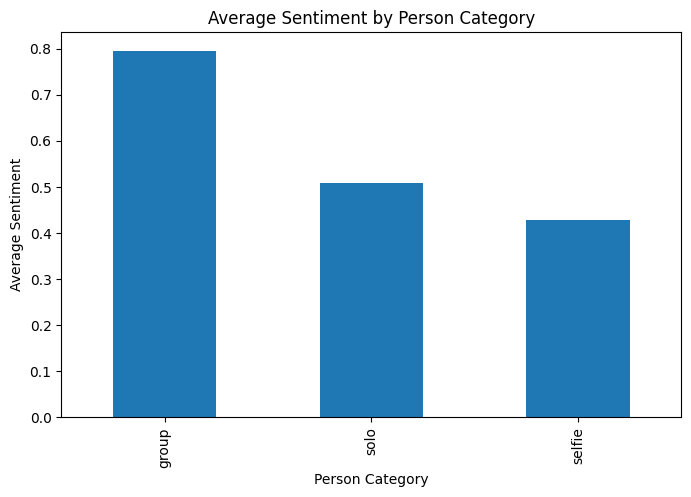


IMAGE COUNT BY CONTEXT CATEGORY

context
sport_gym    362
outdoors     251
everyday     242
other        189
animal       149
Name: count, dtype: int64

Average Sentiment by CONTEXT Category

context
outdoors     0.553668
animal       0.534191
sport_gym    0.506874
other        0.493292
everyday     0.466123
Name: sentiment, dtype: float64


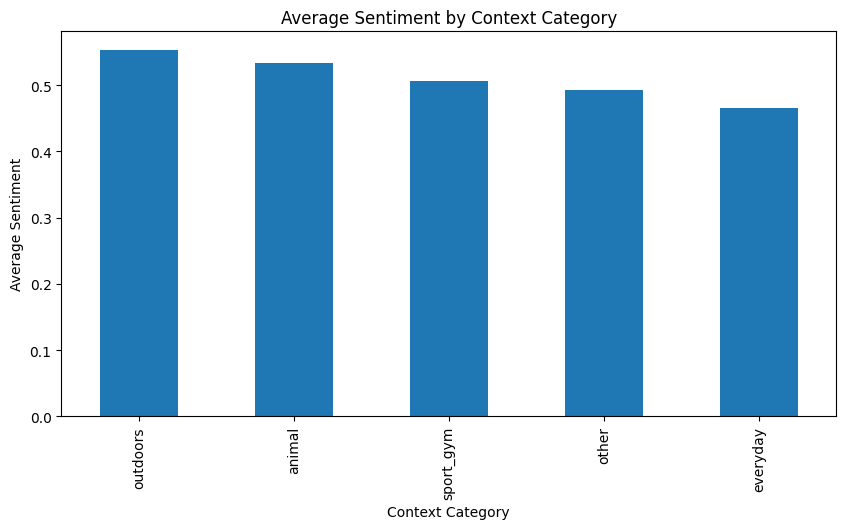


IMAGE COUNT BY PERSON × CONTEXT

    person    context  image_count
11    solo  sport_gym          339
10    solo   outdoors          251
8     solo   everyday          236
9     solo      other          182
7     solo     animal          147
6   selfie  sport_gym           20
4   selfie   everyday            5
1    group      other            5
2    group  sport_gym            3
3   selfie     animal            2
5   selfie      other            2
0    group   everyday            1
    person    context  avg_sentiment  image_count
0    group   everyday       0.921100            1
2    group  sport_gym       0.847146            3
1    group      other       0.740450            5
3   selfie     animal       0.564114            2
10    solo   outdoors       0.553668          251
7     solo     animal       0.533784          147
11    solo  sport_gym       0.507019          339
9     solo      other       0.487358          182
8     solo   everyday       0.468183          236
6   selfie 

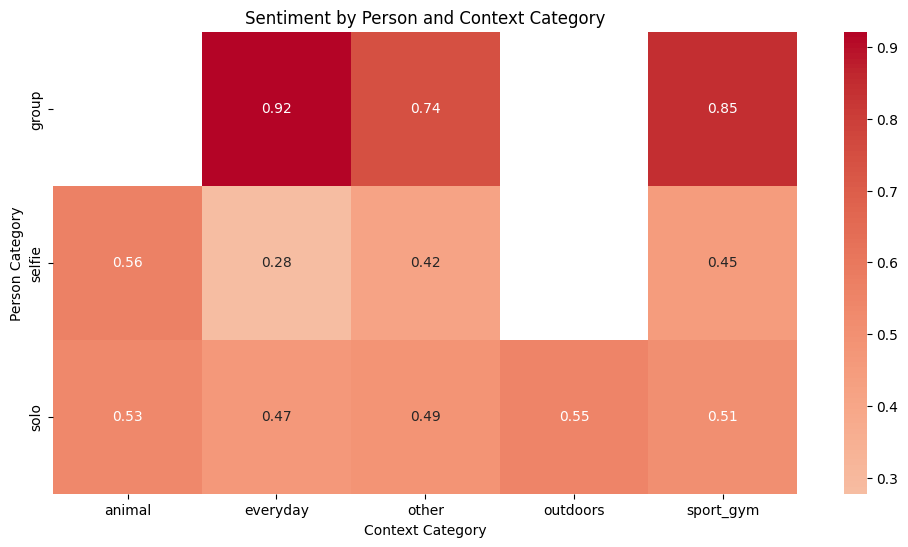


Top 10 Most Positive Image Types

    person    context  avg_sentiment  image_count
0    group   everyday       0.921100            1
2    group  sport_gym       0.847146            3
1    group      other       0.740450            5
3   selfie     animal       0.564114            2
10    solo   outdoors       0.553668          251
7     solo     animal       0.533784          147
11    solo  sport_gym       0.507019          339
9     solo      other       0.487358          182
8     solo   everyday       0.468183          236
6   selfie  sport_gym       0.453387           20

Top 10 Most Negative Image Types

    person    context  avg_sentiment  image_count
1    group      other       0.740450            5
3   selfie     animal       0.564114            2
10    solo   outdoors       0.553668          251
7     solo     animal       0.533784          147
11    solo  sport_gym       0.507019          339
9     solo      other       0.487358          182
8     solo   everyday       0.

In [ ]:
# ============================================================
# COMPLETE IMAGE + COMMENT ANALYSIS PIPELINE
# ===========================================================
'''Note: This model does not extract topics from comments unlike the one above.
Each image inherits the average sentiment of all comments on its post. So the model is estimating:
“When a post contains this type of image, how positive are the comments overall?”
#Not:
“Are people praising or criticizing the specific feature in the image?” Ex. For a comment like "The gym photo is good but remove the selfie photo"
if the sentiment of this comment is = +0.3 that will be applied to both the gym photo and the selfie photo.
'''
# This pipeline:
# 1. Loads dataset
# 2. Computes sentiment from comments
# 3. Converts dataset to IMAGE-LEVEL rows
# 4. Computes marginal sentiment by person category
# 5. Computes marginal sentiment by context category
# 6. Computes sentiment for ALL 32 person-context combinations
# 7. Generates visualizations (bar charts + heatmap)
# ============================================================


# ============================================================
# SECTION 1 — IMPORT LIBRARIES
# ============================================================

import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ============================================================
# SECTION 2 — LOAD DATASET
# ============================================================

with open("profile_review_posts(real).json","r") as f:
    raw_data = json.load(f)

dataset = pd.DataFrame(raw_data)

dataset = dataset.rename(columns={"id":"post_id"})

print("Total posts:", len(dataset))


# ============================================================
# SECTION 3 — INITIALIZE SENTIMENT MODEL
# ============================================================

analyzer = SentimentIntensityAnalyzer()


# ============================================================
# SECTION 4 — COMPUTE SENTIMENT PER COMMENT
# ============================================================

all_comments = []

for i, row in dataset.iterrows():

    comments = row["comments"]

    if isinstance(comments, list):

        for c in comments:

            text = c.get("body", "")

            score = analyzer.polarity_scores(text)["compound"]

            all_comments.append({
                "post_id": row["post_id"],
                "comment": text,
                "sentiment": score
            })

comments_df = pd.DataFrame(all_comments)

print("Total comments:", len(comments_df))


# ============================================================
# SECTION 5 — COMPUTE AVERAGE SENTIMENT PER POST
# ============================================================

post_sentiment = (
    comments_df
    .groupby("post_id")["sentiment"]
    .mean()
    .reset_index()
)

print(dataset.columns)
print(post_sentiment.columns)


dataset = dataset.merge(post_sentiment, on="post_id")

print("Posts with sentiment:", len(dataset))


# ============================================================
# SECTION 6 — CONVERT DATASET TO IMAGE-LEVEL ROWS
# ============================================================

# Each image becomes a row
# Images inherit sentiment from the post

image_rows = []

for _, row in dataset.iterrows():

    persons = row["person_labels"]
    contexts = row["context_labels"]

    if isinstance(persons, dict):

        for img in persons.keys():

            person = persons.get(img)
            context = contexts.get(img)

            image_rows.append({
                "post_id": row["post_id"],
                "image": img,
                "person": person,
                "context": context,
                "sentiment": row["sentiment"]
            })

image_df = pd.DataFrame(image_rows)

print("Total images:", len(image_df))


# ============================================================
# SECTION 7 — CLEAN DATA
# ============================================================

image_df = image_df.dropna(subset=["person","context","sentiment"])

print("Images after cleaning:", len(image_df))


# ============================================================
# SECTION 8 — MARGINAL SENTIMENT BY PERSON CATEGORY
# ============================================================

print("\nIMAGE COUNT BY PERSON CATEGORY\n")

person_counts = image_df["person"].value_counts()

print(person_counts)

person_sentiment = (
    image_df
    .groupby("person")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Sentiment by PERSON Category\n")
print(person_sentiment)


# ============================================================
# SECTION 9 — VISUALIZATION: PERSON SENTIMENT
# ============================================================

plt.figure(figsize=(8,5))

person_sentiment.plot(kind="bar")

plt.title("Average Sentiment by Person Category")
plt.ylabel("Average Sentiment")
plt.xlabel("Person Category")

plt.show()


# ============================================================
# SECTION 10 — MARGINAL SENTIMENT BY CONTEXT CATEGORY
# ============================================================
print("\nIMAGE COUNT BY CONTEXT CATEGORY\n")

context_counts = image_df["context"].value_counts()

print(context_counts)

context_sentiment = (
    image_df
    .groupby("context")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Sentiment by CONTEXT Category\n")
print(context_sentiment)


# ============================================================
# SECTION 11 — VISUALIZATION: CONTEXT SENTIMENT
# ============================================================

plt.figure(figsize=(10,5))

context_sentiment.plot(kind="bar")

plt.title("Average Sentiment by Context Category")
plt.ylabel("Average Sentiment")
plt.xlabel("Context Category")

plt.show()


# ============================================================
# SECTION 12 — SENTIMENT FOR ALL 32 PERSON × CONTEXT COMBINATIONS
# ============================================================
print("\nIMAGE COUNT BY PERSON × CONTEXT\n")

combo_counts = (
    image_df
    .groupby(["person","context"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print(combo_counts)

combo_sentiment = (
    image_df
    .groupby(["person","context"])
    .agg(
        avg_sentiment=("sentiment","mean"),
        image_count=("sentiment","size")
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

print(combo_sentiment)


# ============================================================
# SECTION 13 — CREATE PERSON × CONTEXT MATRIX
# ============================================================

heatmap_data = image_df.pivot_table(
    values="sentiment",
    index="person",
    columns="context",
    aggfunc="mean"
)

print("\nSentiment Matrix\n")
print(heatmap_data)


# ============================================================
# SECTION 14 — HEATMAP VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Sentiment by Person and Context Category")

plt.xlabel("Context Category")
plt.ylabel("Person Category")

plt.show()


# ============================================================
# SECTION 15 — TOP AND BOTTOM IMAGE TYPES
# ============================================================

print("\nTop 10 Most Positive Image Types\n")
print(combo_sentiment.head(10))

print("\nTop 10 Most Negative Image Types\n")
print(combo_sentiment.tail(10))


# ============================================================
# PIPELINE COMPLETE
# ============================================================

print("\nPipeline Complete")

In [ ]:
post_sentiment.to_csv("post_sentiment.csv", index=False)
meta.to_csv("meta.csv", index=False)